
# 📚 Análise de Dados - Desafio Alura Store

Este notebook tem como objetivo analisar o desempenho de quatro lojas pertencentes à rede Alura Store, para auxiliar o Sr. João a decidir qual loja vender.
As métricas principais analisadas são:
- Faturamento total
- Produtos mais e menos vendidos
- Avaliação média dos clientes
- Custo médio do frete
- Ticket médio


### Importação dos dados



In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

lojas = [loja, loja2, loja3, loja4]
loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


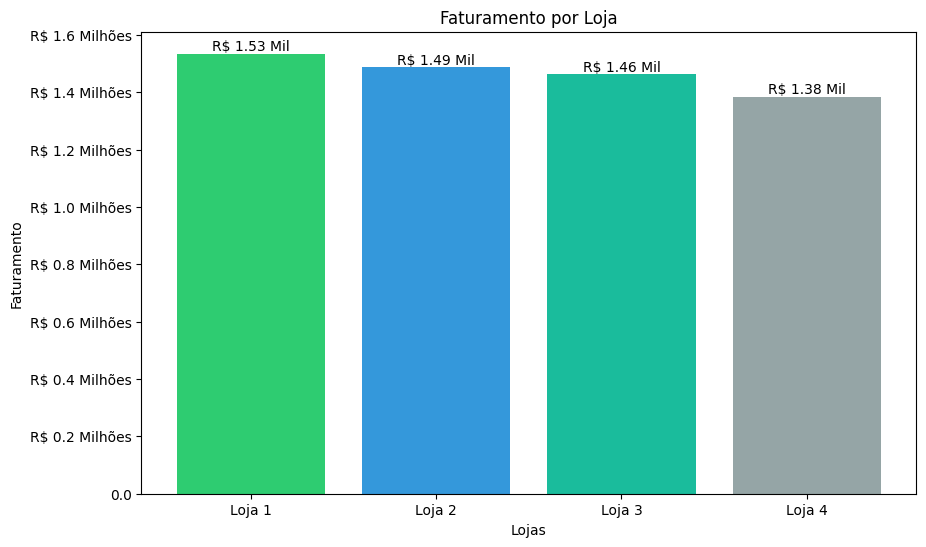

,Faturamento
Loja 1,1534509.12
Loja 2,1488459.06
Loja 3,1464025.03
Loja 4,1384497.58


In [18]:
faturamento_loja1 = sum(loja['Preço'])
faturamento_loja2 = sum(loja2['Preço'])
faturamento_loja3 = sum(loja3['Preço'])
faturamento_loja4 = sum(loja4['Preço'])

faturamentos = [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]
lojas_nome = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

plt.figure(figsize=(10, 6))
barras = plt.bar(lojas_nome, faturamentos, color= ['#2ECC71', '#3498DB', '#1ABC9C', '#95A5A6'])
plt.xticks(rotation=0)
plt.xlabel('Lojas')
plt.ylabel('Faturamento')
plt.title('Faturamento por Loja')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f} Milhões'if x > 0 else f'{x/1_000_000:.1f}')) # pegando o a figura atual, e
plt.gca().bar_label(barras, labels= (f'R$ {v/1_000_000:.2f} Mil' for v in faturamentos))
plt.show()

df_faturamentos = pd.DataFrame(faturamentos, index=lojas_nome, columns=['Faturamento'])
df_faturamentos


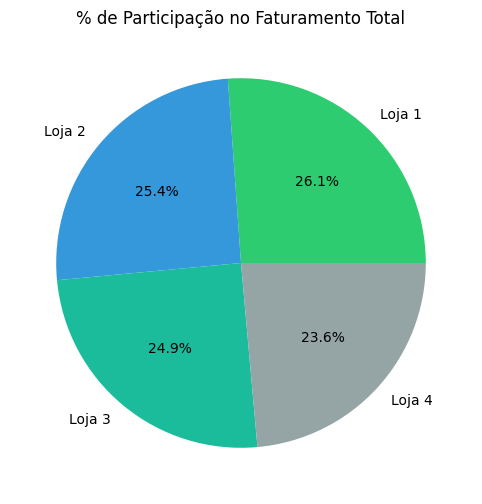

In [19]:
plt.figure(figsize=(10, 6))
plt.pie(faturamentos, labels=lojas_nome, autopct='%1.1f%%', colors= ['#2ECC71', '#3498DB', '#1ABC9C', '#95A5A6'])
plt.title('% de Participação no Faturamento Total')
plt.show()

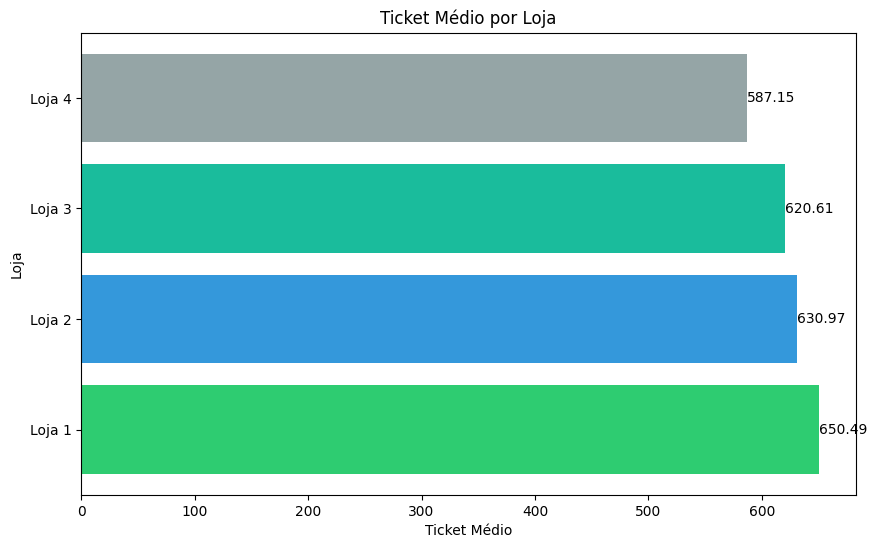

In [20]:
# prompt: faça um gráfico de barras horizontal em ordem de valor que mostre um dataframe de ticket  médio (faturamento total  de loja/ pedidos totais da loka) arredonde por 2 casas decimais os valores do ticket médio no dataframe, gere um dataframe em ordem de valores, coloque os rótulos das barras

import pandas as pd
import matplotlib.pyplot as plt

# Calculate ticket médio for each store
ticket_medio_loja1 = round(faturamento_loja1 / len(loja), 2)
ticket_medio_loja2 = round(faturamento_loja2 / len(loja2), 2)
ticket_medio_loja3 = round(faturamento_loja3 / len(loja3), 2)
ticket_medio_loja4 = round(faturamento_loja4 / len(loja4), 2)

# Create a DataFrame
ticket_medio_data = {
    'Loja': lojas_nome,
    'Ticket Médio': [ticket_medio_loja1, ticket_medio_loja2, ticket_medio_loja3, ticket_medio_loja4]
}
df_ticket_medio = pd.DataFrame(ticket_medio_data)

# Sort the DataFrame by Ticket Médio

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(df_ticket_medio['Loja'], df_ticket_medio['Ticket Médio'], color=['#2ECC71', '#3498DB', '#1ABC9C', '#95A5A6'])
plt.xlabel('Ticket Médio')
plt.ylabel('Loja')
plt.title('Ticket Médio por Loja')

# Add labels to the bars
for index, value in enumerate(df_ticket_medio['Ticket Médio']):
    plt.text(value, index, str(value), va='center')
df_ticket_medio

plt.show()


# 2. Vendas por Categoria


In [21]:
vendas_por_categoria = {}
def vendas_categoria(loja):
  return loja.groupby('Categoria do Produto')['Preço'].sum().round(2)

cat1 = vendas_categoria(loja)
cat2 = vendas_categoria(loja2)
cat3 = vendas_categoria(loja3)
cat4 = vendas_categoria(loja4)

vendas_por_categoria['Loja 1'] = cat1
vendas_por_categoria['Loja 2'] = cat2
vendas_por_categoria['Loja 3'] = cat3
vendas_por_categoria['Loja 4'] = cat4


<Figure size 1000x600 with 0 Axes>

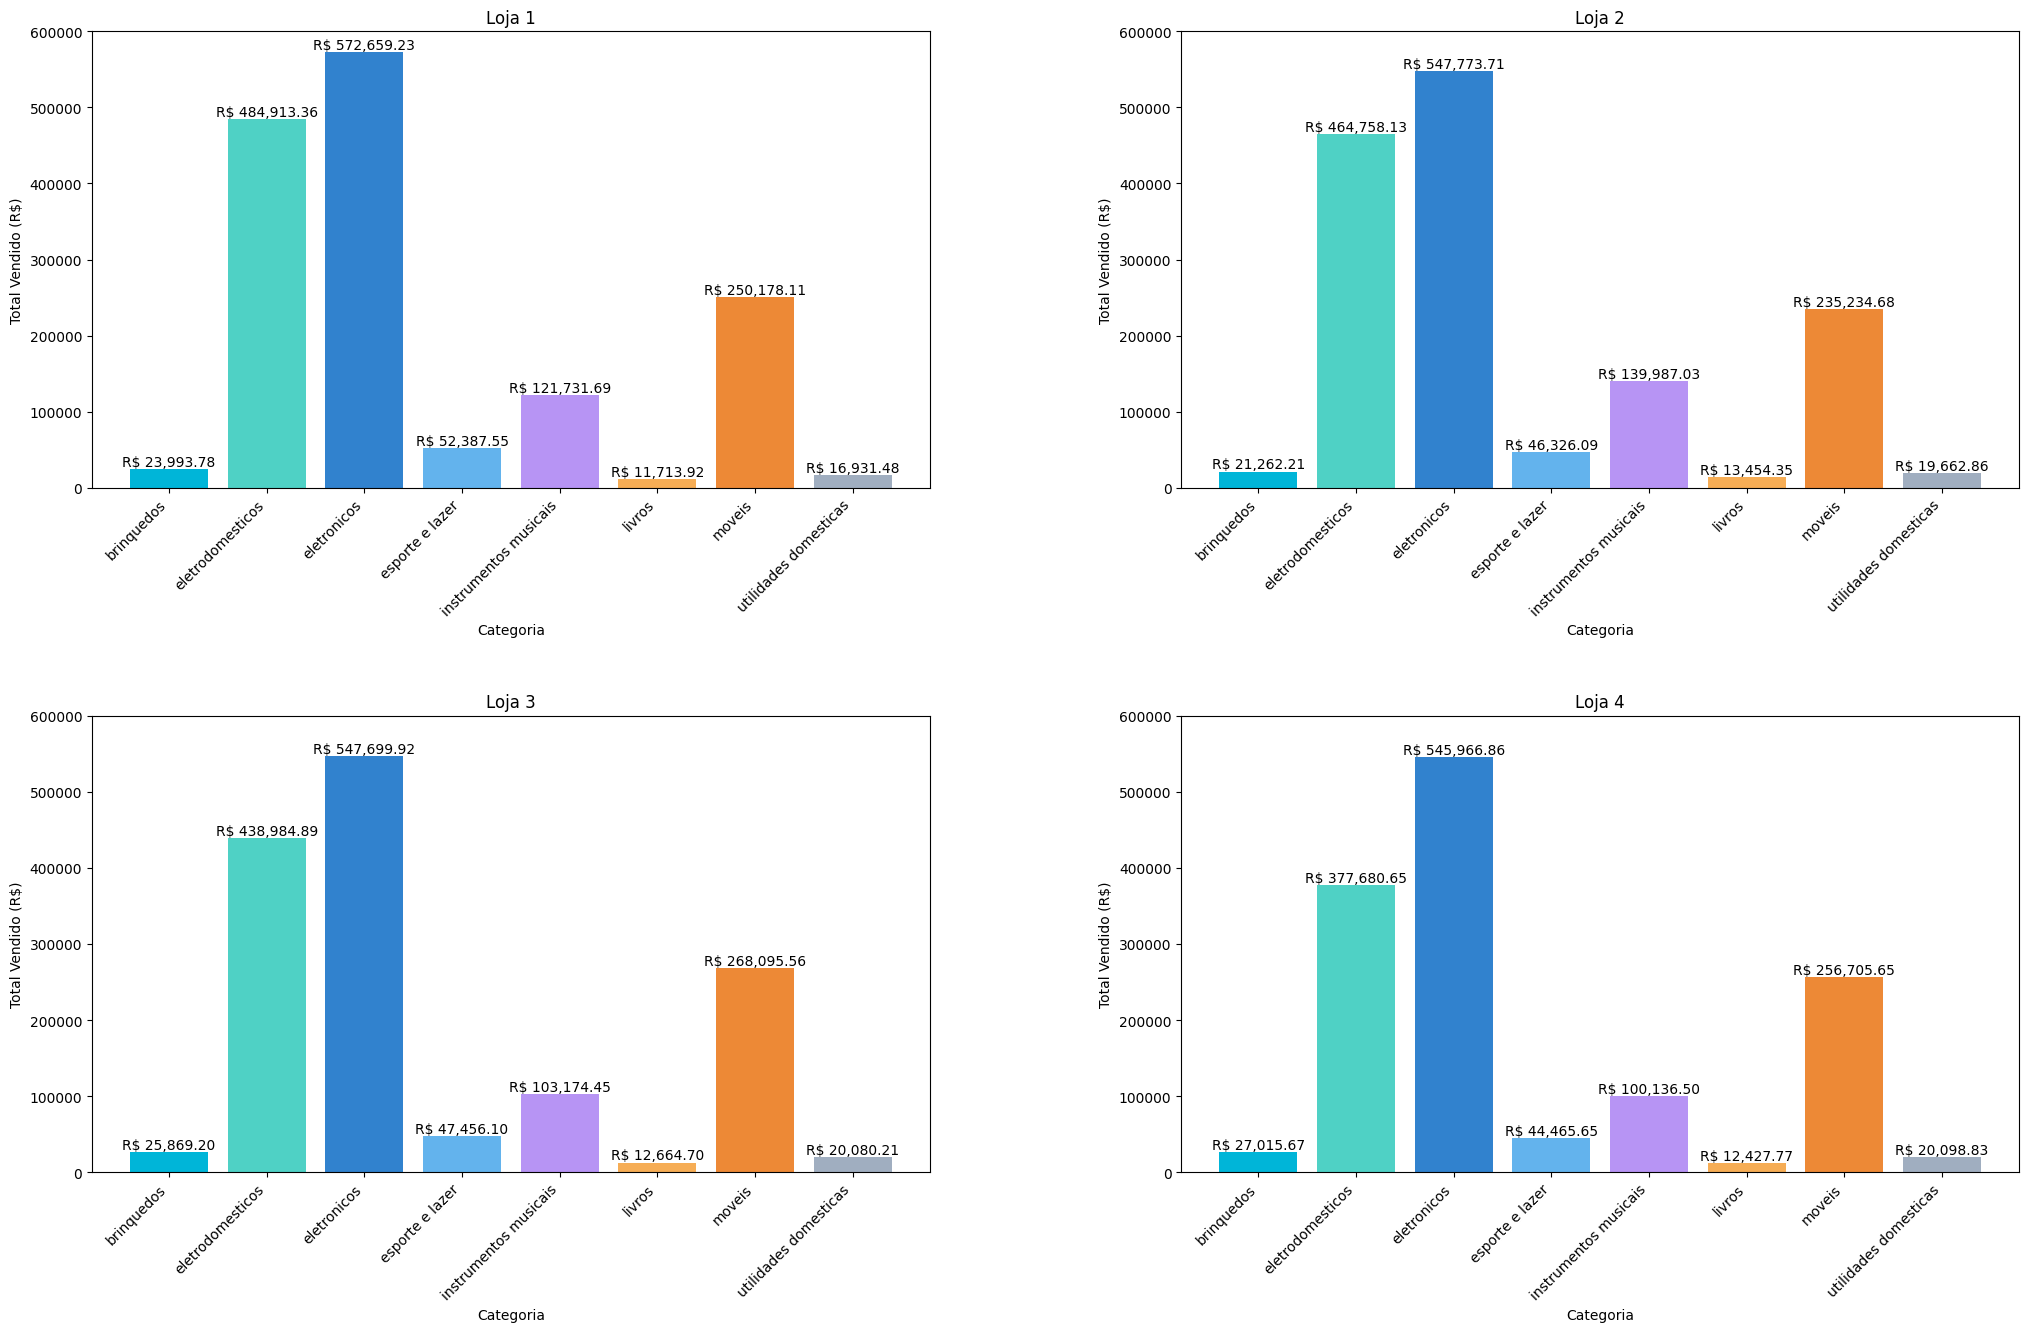

In [22]:
plt.figure(figsize=(10, 6))

colors = [
    '#00B5D8',  # brinquedos
    '#4FD1C5',  # eletrodomesticos
    '#3182CE',  # eletronicos
    '#63B3ED',  # esporte e lazer
    '#B794F4',  # instrumentos musicais
    '#F6AD55',  # livros
    '#ED8936',  # moveis
    '#A0AEC0'   # utilidades domesticas
]

fig, axes = plt.subplots(figsize=(20, 12), nrows=2, ncols=2)
plt.tight_layout()

loja_index = 0
axes = axes.flatten()
for loja in vendas_por_categoria:
    valores  = vendas_por_categoria[loja]
    categorias = valores.index


    barra = axes[loja_index].bar(categorias, valores, color=colors)
    axes[loja_index].bar_label(barra, labels= (f'R$ {v:,.2f}' for v in valores))
    axes[loja_index].set_title(loja)
    axes[loja_index].set_ylabel('Total Vendido (R$)')
    axes[loja_index].set_xlabel('Categoria')
    axes[loja_index].set_ylim(0, 600000)

    plt.setp(axes[loja_index].get_xticklabels(), rotation=45, ha='right')

    loja_index += 1
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

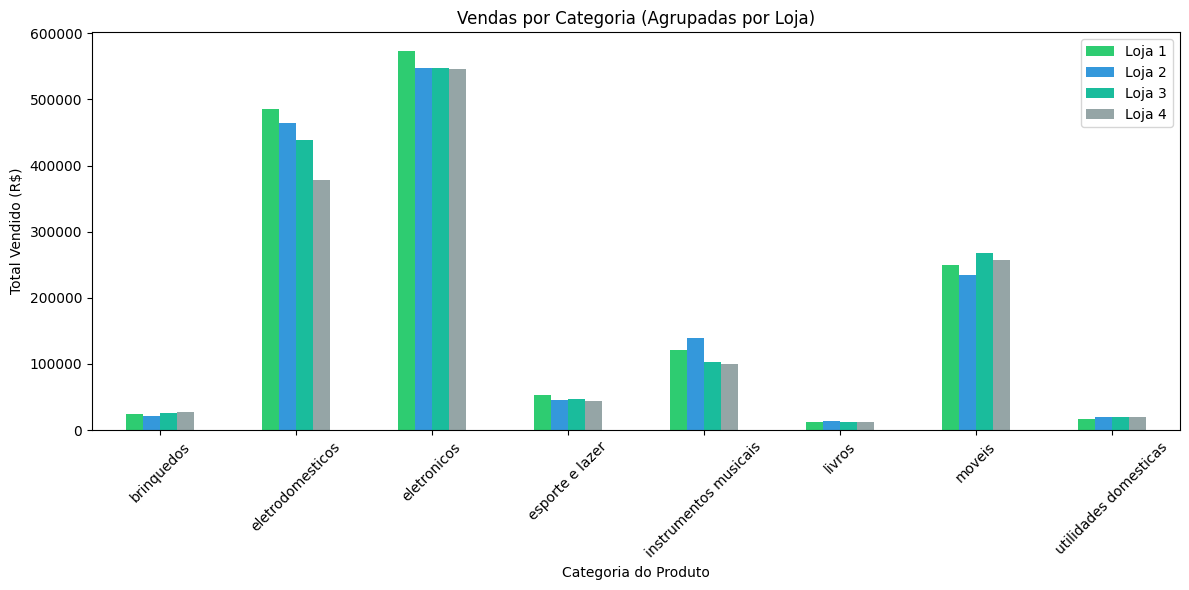

,Loja 1,Loja 2,Loja 3,Loja 4
Categoria do Produto,,,,
brinquedos,23993.78,21262.21,25869.20,27015.67
eletrodomesticos,484913.36,464758.13,438984.89,377680.65
eletronicos,572659.23,547773.71,547699.92,545966.86
esporte e lazer,52387.55,46326.09,47456.10,44465.65
instrumentos musicais,121731.69,139987.03,103174.45,100136.50
livros,11713.92,13454.35,12664.70,12427.77
moveis,250178.11,235234.68,268095.56,256705.65
utilidades domesticas,16931.48,19662.86,20080.21,20098.83


In [23]:
# Criar um dicionário com os dados das vendas por categoria para cada loja
vendas_por_categoria = {}
for i, loja in enumerate(lojas, 1):
    vendas_por_categoria[f'Loja {i}'] = loja.groupby('Categoria do Produto')['Preço'].sum().round(2)

# Criar um DataFrame a partir do dicionário
df_vendas = pd.DataFrame(vendas_por_categoria)
cores = ['#2ECC71', '#3498DB', '#1ABC9C', '#95A5A6']
# Plotar o gráfico de barras agrupadas lado a lado
ax = df_vendas.plot.bar(figsize=(12, 6), rot=45, color=cores)

# Configurar o gráfico
ax.set_ylabel('Total Vendido (R$)')
ax.set_title('Vendas por Categoria (Agrupadas por Loja)')
plt.tight_layout()  # Ajustar o layout para evitar sobreposição de elementos
plt.show()

df_vendas

# 3. Média de Avaliação das Lojas

In [24]:
media_avaliacao = []
for i, loja in enumerate(lojas):
  media_avaliacao.append(round(np.average(loja['Avaliação da compra']), 2))
  medias_lojas = pd.DataFrame(media_avaliacao, columns=['Média de Avaliação'])
medias_lojas.index = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
medias_lojas


,Média de Avaliação
Loja 1,3.98
Loja 2,4.04
Loja 3,4.05
Loja 4,4.00


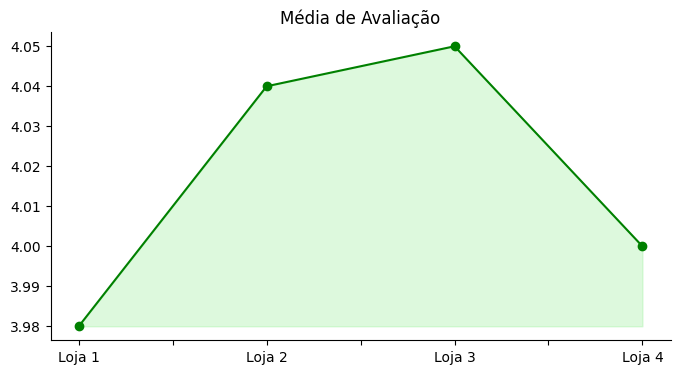

In [25]:
import matplotlib.pyplot as plt
medias_lojas['Média de Avaliação'].plot(kind='line', figsize=(8, 4), title='Média de Avaliação', color='Green', marker='o')
plt.fill_between(medias_lojas.index, medias_lojas['Média de Avaliação'], 3.98, color='lightgreen', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

produtos_mais_vendidos = {}
produtos_menos_vendidos = {}

for i, loja in enumerate(lojas):
    quantidade_vendida = loja['Produto'].value_counts()
    produto_mais_vendido = quantidade_vendida.idxmax()
    produto_menos_vendido = quantidade_vendida.idxmin()

    produtos_mais_vendidos[f'Loja {i+1}'] = (produto_mais_vendido, quantidade_vendida.max())
    produtos_menos_vendidos[f'Loja {i+1}'] = (produto_menos_vendido, quantidade_vendida.min())



df_produtos = pd.DataFrame({
    'Produtos mais vendidos': [produto for produto, quantidade in produtos_mais_vendidos.values()],
    'Qtd_mais': [quantidade for produto, quantidade in produtos_mais_vendidos.values()],
    'Produtos menos vendidos': [produto for produto, quantidade in produtos_menos_vendidos.values()],
    'Qtd_menos': [quantidade for produto, quantidade in produtos_menos_vendidos.values()]
})
df_produtos.index = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
print(df_produtos)

          Produtos mais vendidos  Qtd_mais Produtos menos vendidos  Qtd_menos
Loja 1               Micro-ondas        60                 Headset         33
Loja 2  Iniciando em programação        65       Jogo de tabuleiro         32
Loja 3             Kit banquetas        57        Blocos de montar         35
Loja 4                  Cama box        62                Guitarra         33


# 5. Frete Médio por Loja


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fretes_por_loja = {}
for i, loja in enumerate(lojas):
  media_frete = loja['Frete'].mean()
  fretes_por_loja[f'Loja {i+1}'] = round(media_frete, 2)

df_frete_medio = pd.DataFrame(fretes_por_loja.items(), columns=['Loja', 'Frete Médio'])
df_frete_medio.set_index('Loja', inplace=True)

df_frete_medio

,Frete Médio
Loja,
Loja 1,34.69
Loja 2,33.62
Loja 3,33.07
Loja 4,31.28


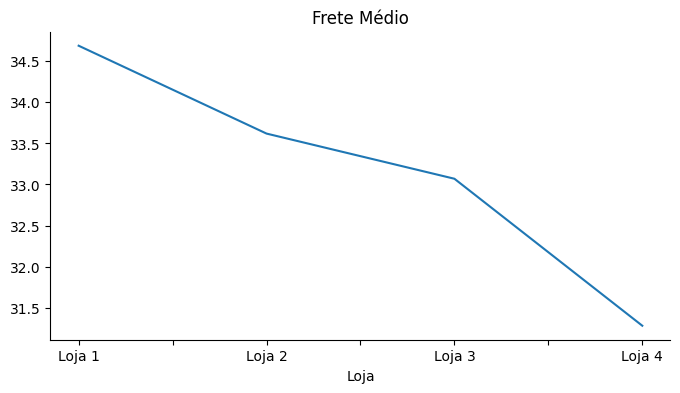

In [28]:
from matplotlib import pyplot as plt
df_frete_medio['Frete Médio'].plot(kind='line', figsize=(8, 4), title='Frete Médio')
plt.gca().spines[['top', 'right']].set_visible(False)

# 6. Avaliando o faturamento mensal

Este trecho tem como objetivo analisar e visualizar o faturamento mensal de cada loja de acordo com a média de vendas. Ele processa os dados, organiza-os por mês e ano, e então gera gráficos de linhas para mostrar a evolução do faturamento ao longo do tempo.


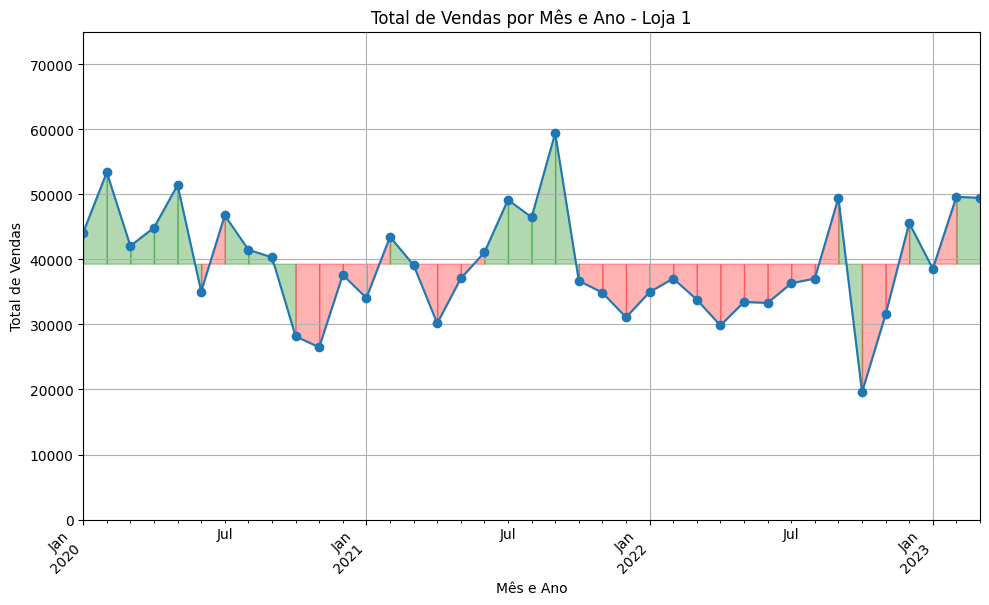

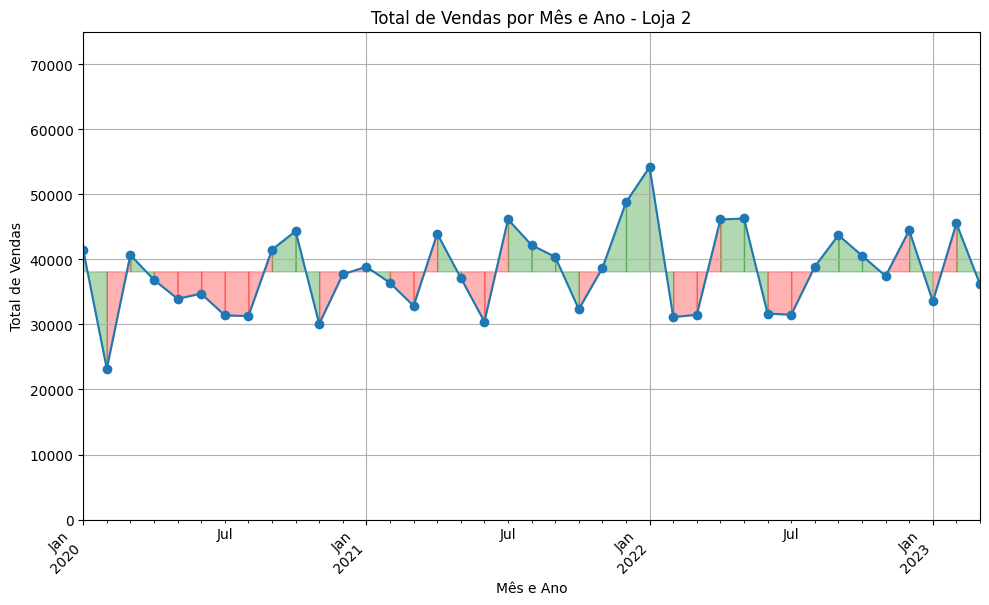

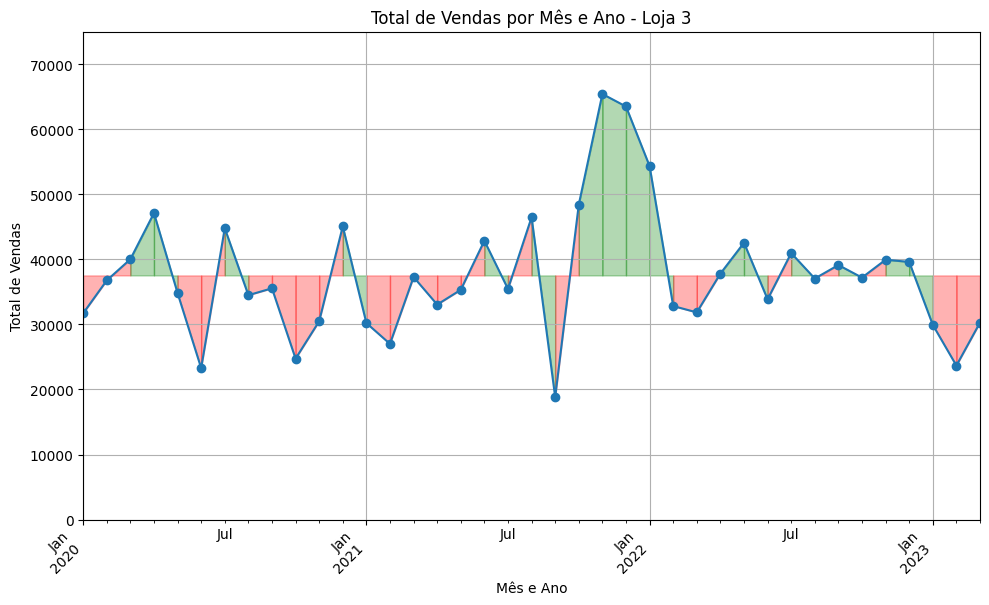

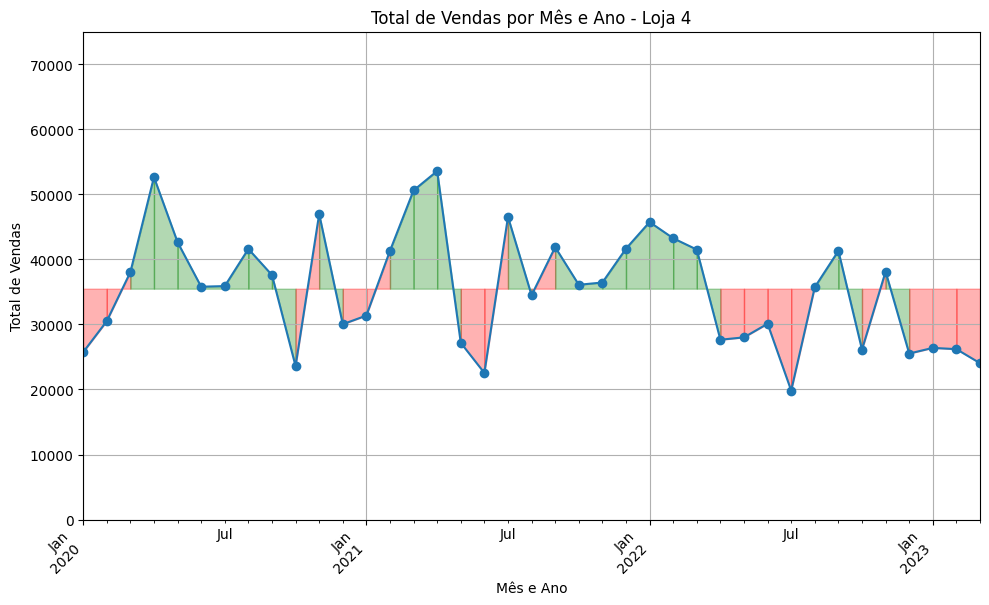

In [29]:
total_vendas_por_mes_ano_por_loja = {}

for i, loja in enumerate(lojas, 1):
    loja['Data da Compra'] = pd.to_datetime(loja['Data da Compra'], format='%d/%m/%Y')
    loja['MesAno'] = loja['Data da Compra'].dt.to_period('M')  # Criando coluna 'MesAno'
    total_vendas_por_mes_ano = loja.groupby('MesAno')['Preço'].sum()
    total_vendas_por_mes_ano_por_loja[f'Loja {i}'] = total_vendas_por_mes_ano

df_total_vendas_por_mes_ano = pd.DataFrame(total_vendas_por_mes_ano_por_loja)

# Criando um gráfico de linhas para cada loja
for loja in df_total_vendas_por_mes_ano.columns:
    plt.figure(figsize=(10, 6))  # Cria uma nova figura para cada loja
    df_total_vendas_por_mes_ano[loja].plot(kind='line', marker='o')  # Plota a linha com marcadores

    x_values = df_total_vendas_por_mes_ano.index
    y_values = df_total_vendas_por_mes_ano[loja]
    media = y_values.mean()

    # Preenchimento colorido com lógica corrigida e acesso por .iloc
    for i in range(len(x_values) - 1):
        if y_values.iloc[i] >= media:  # Usando .iloc para acessar por posição
            plt.fill_between([x_values[i], x_values[i+1]], [y_values.iloc[i], y_values.iloc[i+1]], media, color='green', alpha=0.3)
        else:
            plt.fill_between([x_values[i], x_values[i+1]], [y_values.iloc[i], y_values.iloc[i+1]], media, color='red', alpha=0.3)

    plt.title(f'Total de Vendas por Mês e Ano - {loja}')  # Define o título do gráfico
    plt.xlabel('Mês e Ano')
    plt.ylabel('Total de Vendas')
    plt.ylim(0, 75000)
    plt.grid(True)  # Adiciona uma grade ao gráfico
    plt.tight_layout()
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Relatório de Análise de Desempenho das Lojas - Alura Store

**Prezado Sr. João,**

Este relatório tem como objetivo analisar o desempenho de suas quatro lojas, fornecendo informações relevantes para auxiliar na sua tomada de decisão sobre qual loja vender. Para isso, avaliei diferentes aspectos das lojas, como faturamento, produtos mais vendidos, satisfação dos clientes, custo do frete e valor médio das compras.

## 1. Faturamento Total das Lojas:

Observei que existem diferenças significativas no faturamento total de cada loja. A Loja 1 apresentou o maior faturamento, com 1.534.509,12 reais, indicando um desempenho financeiro superior. As Lojas 2 e 3 apresentaram faturamentos próximos, com 1.488.459,06 reais e 1.464.025,03 reais, respectivamente. A Loja 4, por sua vez, teve o menor faturamento, com 1.384.497,58 reais, o que indica um desempenho inferior em relação às outras lojas. Essa análise é crucial para identificar quais lojas geram mais receita e quais precisam de atenção especial.

**Conclusões:**

- A Loja 1 possui o melhor desempenho em termos de faturamento total, possivelmente devido à localização, mix de produtos ou outros fatores que a tornam mais atrativa para os clientes.
- As Lojas 2 e 3 apresentam um desempenho financeiro semelhante, com faturamentos próximos ao da Loja 1.
- A Loja 4 apresenta o menor faturamento, indicando a necessidade de investigar as causas e implementar medidas para aumentar suas vendas.

## 2. Produtos Mais e Menos Vendidos:

Identifiquei os produtos que mais e menos vendem em cada loja. Essa informação é importante para entender quais produtos impulsionam as vendas e quais não geram o interesse esperado dos clientes.

**Conclusões:**

- Através da análise dos produtos mais vendidos em cada loja, é possível identificar tendências de consumo e ajustar o estoque para atender à demanda.
- Os produtos menos vendidos podem indicar a necessidade de rever estratégias de marketing, precificação ou até mesmo descontinuar sua venda.
- É importante realizar uma análise detalhada por categoria de produto para entender as preferências dos clientes em cada loja e otimizar o mix de produtos oferecido.

## 3. Avaliação Média dos Clientes:

A satisfação dos clientes é um fator fundamental para o sucesso de qualquer negócio. A Loja 3 obteve a melhor avaliação média dos clientes, com 4,05, demonstrando alta qualidade no atendimento e nos produtos oferecidos. A Loja 2 teve uma avaliação média de 4,04, seguida pela Loja 4 com 4,00 e pela Loja 1 com 3,98. Lojas com avaliações mais baixas podem indicar a necessidade de melhorias na experiência do cliente.

**Conclusões:**

- A Loja 3 se destaca pela alta satisfação dos clientes, o que pode ser um diferencial competitivo importante.
- As Lojas 2 e 4 também apresentam boas avaliações, indicando um bom nível de atendimento e qualidade dos produtos.
- A Loja 1 possui a menor avaliação média, o que sugere a necessidade de investigar as causas e implementar medidas para melhorar a experiência do cliente, como investir em treinamento da equipe de atendimento ou em melhorias na estrutura da loja.

## 4. Custo Médio do Frete:

O custo do frete é um fator que influencia diretamente a decisão de compra dos clientes. A Loja 4 possui o menor custo médio de frete, com R\$ 31,28, o que pode ser um atrativo para os clientes. As Lojas 2 e 3 apresentam custos de frete intermediários, com 33,62 reais e 33,07 reais, respectivamente. A Loja 1 tem o maior custo médio de frete, com 34,69 reais.

**Conclusões:**

- A Loja 4 possui uma vantagem competitiva em relação ao custo do frete, o que pode atrair clientes que buscam economia na entrega.
- As Lojas 2 e 3 apresentam custos de frete competitivos, que podem não impactar significativamente nas vendas.
- A Loja 1 possui o maior custo de frete, o que pode ser um fator limitante para alguns clientes, especialmente em compras de menor valor.

## 5. Ticket Médio:

O ticket médio representa o valor médio gasto por cada cliente em um pedido. A Loja 1 apresenta o maior ticket médio, com 650,49 reais, indicando que os clientes que compram nessa loja tendem a gastar mais por pedido. A Loja 2 teve um ticket médio de 630,97 reais, seguida pela Loja 3 com 620,61 reais e pela Loja 4 com 587,15 reais.

**Conclusões:**

- A Loja 1 possui clientes com maior poder de compra ou oferece produtos com maior valor agregado, resultando em um ticket médio mais alto.
- As Lojas 2 e 3 apresentam tickets médios próximos, indicando um perfil de cliente semelhante.
- A Loja 4 possui o menor ticket médio, o que pode indicar a necessidade de oferecer produtos com maior valor agregado ou implementar estratégias para aumentar o valor das compras, como oferecer promoções de up-selling ou cross-selling.

## 6. Avaliando o Faturamento Mensal

Analisei o faturamento mensal de cada loja para identificar tendências e variações ao longo do tempo. Para isso, processei os dados de vendas, organizei-os por mês e ano e, em seguida, gerei gráficos de linhas para visualizar a evolução do faturamento.

Observei que a Loja 4 apresentou um faturamento abaixo da média nos últimos 4 meses, com valores na faixa de R\$ 20.000-30.000, enquanto as outras lojas se mantiveram em faixas superiores. Além disso, notei que a Loja 1 apresentou um crescimento consistente ao longo do ano, enquanto as Lojas 2 e 3 tiveram um desempenho mais estável.

**Conclusões:**

- A análise do faturamento mensal permite identificar padrões e tendências importantes para o negócio.
- É possível observar quais lojas apresentam crescimento, estabilidade ou queda nas vendas ao longo do tempo.
- Essa informação é crucial para tomar decisões estratégicas, como ajustar o estoque, implementar campanhas de marketing ou realocar recursos entre as lojas.

## Conclusões da Análise:

Após analisar todos os indicadores, percebi que a Loja 4 apresenta o menor faturamento, menor ticket médio e segunda pior avaliação, apesar de ter o menor custo de frete relativamente. Esses dados indicam que, embora a Loja 4 tenha custos de entrega mais baixos, ela ainda enfrenta desafios em relação ao faturamento e ao valor médio das compras.

# ✅ Conclusão Final

Após analisar as métricas:
- **Loja 4** apresenta o **menor faturamento**, **segunda pior avaliação média** e **menor ticket médio**, além do faturamento mensal estar mais frequentemente na faixa de R\$ 20.000-30.000, especialmente nos **últimos 4 meses seguidos**, apresentando resultados abaixo da média e em tendência de queda.

## Recomendação:

Com base nas análises realizadas, **recomendo que o Sr. João venda a Loja 4**, pois ela apresenta o menor faturamento, menor ticket médio e a segunda pior avaliação das lojas, apesar de ter o menor custo de frete. Esses indicadores sugerem que a Loja 4 pode estar com dificuldades para atrair clientes e gerar receita, mesmo com custos de entrega mais baixos.

## Comparativo entre as Lojas:

| Loja   | Faturamento Total | Avaliação Média | Frete Médio | Ticket Médio |
|--------|-------------------|------------------|--------------|---------------|
| Loja 1 | R\$ 1.534.509,12  | 3.98             | R\$ 34,69    | R\$ 650,49    |
| Loja 2 | R\$ 1.488.459,06  | 4.04             | R\$ 33,62    | R\$ 630,97    |
| Loja 3 | R\$ 1.464.025,03  | 4.05             | R\$ 33,07    | R\$ 620,61    |
| Loja 4 | R\$ 1.384.497,58  | 4.00             | R\$ 31,28    | R\$ 587,15    |

